# Forecasting retail demand under stockouts on GPU

The [FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)
dataset contains 50,000 daily store-product series, each with 90 days of sales,
hourly stockout labels, and promotion and calendar covariates. Observed sales are a
censored version of demand: a store cannot sell an item that is not on the shelf.

This example ports Juan Orduz's
[full-panel NumPyro analysis](https://juanitorduz.github.io/fresh_retail_stockout/)
to PyMC-Forecast. It keeps the whole 50K panel and fits ADVI with the JAX backend,
so the optimization scan runs on the available accelerator. Prediction is
deliberately different: posterior draws are generated in bounded batches on CPU,
and PyMC's posterior-predictive sampler iterates over those host-backed draws. This
prevents the 500-draw, time-by-series tensors from becoming one giant GPU allocation.

The final section changes future availability to one. That turns a forecast of
censored sales into the counterfactual demand forecast an inventory planner needs.

## Runtime configuration

A full run needs a machine with a CUDA JAX installation and ample host RAM. For
example, install the notebook dependencies and replace the CPU JAX wheel with the
CUDA wheel appropriate for the machine:

```bash
uv sync --all-extras --group notebooks
uv pip install --upgrade "jax[cuda12]"
uv run jupyter lab docs/examples/fresh_retail_stockout.ipynb
```

`PYMC_FORECAST_SMOKE_TEST=1` switches to a small synthetic panel and short fit. CI
uses that path to execute every cell without downloading the 106 MB parquet file.

In [1]:
import os

import arviz as az
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pooch
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import Forecaster, ForecastingModel
from pymc_forecast.metrics import evaluate_forecast

SEED = 42
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
T_TRAIN = 76
HORIZON = 14
NUM_STEPS = 50 if SMOKE_TEST else 30_000
LEARNING_RATE = 0.001
NUM_SAMPLES = 20 if SMOKE_TEST else 500
POSTERIOR_BATCH_SIZE = 7 if SMOKE_TEST else 50

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print(f"smoke test: {SMOKE_TEST}")
print(f"JAX devices: {jax.devices()}")

smoke test: True
JAX devices: [CpuDevice(id=0)]


## Load and inspect the panel

The full path scans the parquet lazily with Polars. The hourly sales profile is used
to weight availability: losing an hour during the morning sales peak matters more
than losing an hour late at night.

In [2]:
DATA_URL = (
    "https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K/"
    "resolve/main/data/train.parquet"
)
DATA_HASH = "sha256:6706832db892bbae4969c19d87e07975d2543d2ba7d7d4756360654785de5a3d"


def make_synthetic_panel(n_series: int = 12) -> pl.LazyFrame:
    """Small panel with the same columns as FreshRetailNet-50K for CI."""
    rng = np.random.default_rng(SEED)
    dates = pd.date_range("2024-03-17", periods=T_TRAIN + HORIZON, freq="D")
    series = np.arange(n_series)
    time, series_idx = np.meshgrid(np.arange(len(dates)), series, indexing="ij")
    n_rows = time.size

    hourly_profile = np.exp(-0.5 * ((np.arange(24) - 12.0) / 4.0) ** 2)
    hourly_profile /= hourly_profile.sum()
    availability = np.clip(rng.beta(7, 2, n_rows), 0.0, 1.0)
    availability[rng.random(n_rows) < 0.04] = 0.0
    hourly_stockout = rng.random((n_rows, 24)) > availability[:, None]

    discount = np.where(rng.random(n_rows) < 0.25, rng.uniform(0.75, 0.95, n_rows), 1.0)
    activity = (discount < 1.0).astype(float)
    holiday = np.asarray(
        (pd.DatetimeIndex(np.repeat(dates, n_series)).dayofweek >= 5).astype(float)
    )
    base = 8.0 + 0.4 * series_idx.ravel()
    weekly = 1.0 + 0.18 * np.sin(2 * np.pi * time.ravel() / 7)
    launch = 1.0 + 0.35 * (time.ravel() >= 41)
    latent_demand = base * weekly * launch * (1 + 0.3 * activity)
    floor = 0.06
    sales_factor = floor + (1 - floor) * availability
    sales = np.maximum(
        0.0,
        latent_demand * sales_factor + rng.normal(0, 0.6, n_rows),
    )

    return pl.DataFrame(
        {
            "store_id": (series_idx.ravel() % 4).astype(np.int64),
            "product_id": series_idx.ravel().astype(np.int64),
            "dt": np.asarray(np.repeat(dates.strftime("%Y-%m-%d"), n_series)),
            "sale_amount": sales,
            "hours_sale": (sales[:, None] * hourly_profile[None, :]).tolist(),
            "hours_stock_status": hourly_stockout.astype(np.int8).tolist(),
            "discount": discount,
            "activity_flag": activity,
            "holiday_flag": holiday,
        }
    ).lazy()


if SMOKE_TEST:
    data_lf = make_synthetic_panel()
else:
    parquet_path = pooch.retrieve(
        url=DATA_URL,
        known_hash=DATA_HASH,
        path=pooch.os_cache("pymc_forecast"),
        fname="fresh_retail_train.parquet",
        progressbar=True,
    )
    data_lf = pl.scan_parquet(parquet_path).select(
        "store_id",
        "product_id",
        "dt",
        "sale_amount",
        "hours_sale",
        "hours_stock_status",
        "discount",
        "activity_flag",
        "holiday_flag",
    )

summary = data_lf.select(
    pl.len().alias("rows"),
    pl.struct("store_id", "product_id").n_unique().alias("series"),
    pl.col("store_id").n_unique().alias("stores"),
    pl.col("dt").min().alias("first_day"),
    pl.col("dt").max().alias("last_day"),
).collect(engine="streaming")
summary

rows,series,stores,first_day,last_day
u32,u32,u32,str,str
1080,12,4,"""2024-03-17""","""2024-06-14"""


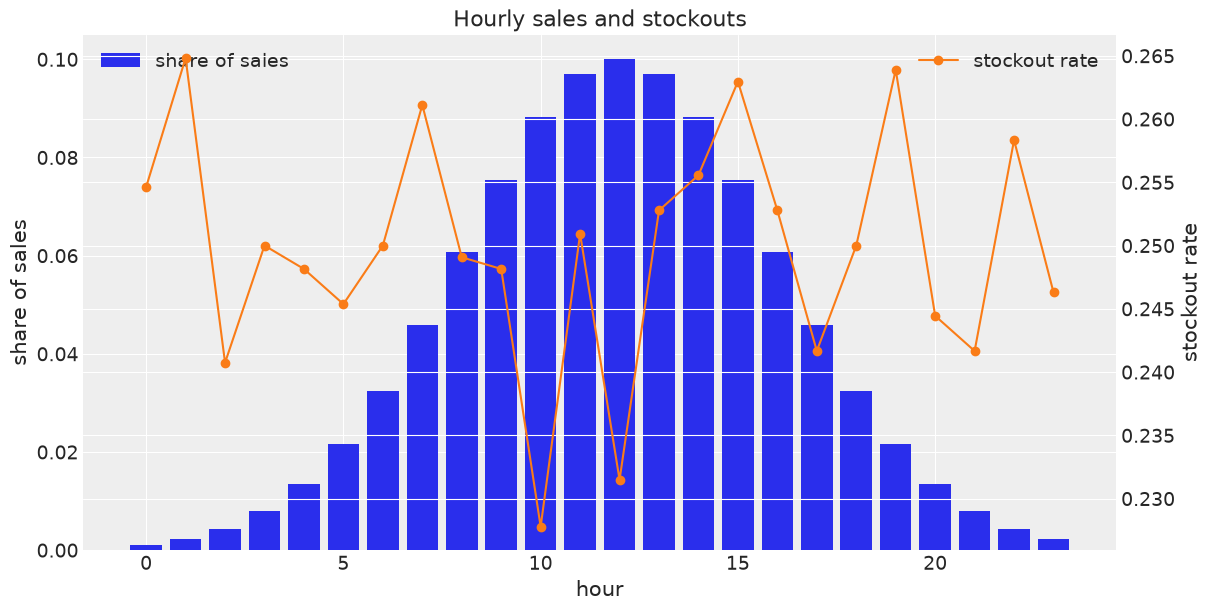

In [3]:
hourly_row = data_lf.select(
    *[pl.col("hours_sale").list.get(hour).sum().alias(f"sales_{hour}") for hour in range(24)],
    *[
        pl.col("hours_stock_status").list.get(hour).mean().alias(f"stockout_{hour}")
        for hour in range(24)
    ],
).collect(engine="streaming")

sales_by_hour = np.asarray(hourly_row.row(0)[:24], dtype=float)
stockout_by_hour = np.asarray(hourly_row.row(0)[24:], dtype=float)
hourly_weights = sales_by_hour / sales_by_hour.sum()

fig, ax = plt.subplots()
ax.bar(np.arange(24), hourly_weights, label="share of sales")
ax2 = ax.twinx()
ax2.plot(np.arange(24), stockout_by_hour, color="C1", marker="o", label="stockout rate")
ax.set(xlabel="hour", ylabel="share of sales", title="Hourly sales and stockouts")
ax2.set(ylabel="stockout rate")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

The sales-weighted availability for day $t$ and series $s$ is

$$a_{t,s} = \sum_{h=0}^{23} w_h(1 - \mathrm{stockout}_{t,s,h}).$$

We also clean `discount == 0`: in this dataset it is an unpriced placeholder,
not a literal 100% discount.

In [4]:
availability_expr = pl.sum_horizontal(
    [
        (1 - pl.col("hours_stock_status").list.get(hour)) * float(hourly_weights[hour])
        for hour in range(24)
    ]
).alias("availability")

discount_expr = (
    pl.when(pl.col("discount") > 0)
    .then((1 - pl.col("discount")).clip(0.0, 1.0))
    .otherwise(0.0)
    .alias("discount_magnitude")
)

panel_df = (
    data_lf.with_columns(
        pl.col("dt").str.to_date(),
        pl.concat_str("store_id", "product_id", separator="::").alias("series_id"),
        availability_expr,
        discount_expr,
    )
    .select(
        "dt",
        "series_id",
        "store_id",
        pl.col("sale_amount").cast(pl.Float32),
        pl.col("availability").cast(pl.Float32),
        pl.col("discount_magnitude").cast(pl.Float32),
        pl.col("activity_flag").cast(pl.Float32),
        pl.col("holiday_flag").cast(pl.Float32),
    )
    .collect(engine="streaming")
    .sort("series_id", "dt")
)

series_ids = panel_df["series_id"].unique().sort().to_list()
dates = panel_df["dt"].unique().sort().to_numpy()
n_series = len(series_ids)
print(f"modeling {n_series:,} series across {len(dates)} days")

modeling 12 series across 90 days


## Named model inputs

Every array below has explicit `time`, `input`, and `series` dimensions. The
per-series scale is computed from the training window only, so the holdout cannot
leak its level into the fit.

In [5]:
def pivot(value: str) -> np.ndarray:
    values = (
        panel_df.pivot(index="dt", on="series_id", values=value)
        .sort("dt")
        .select(series_ids)
        .to_numpy()
        .astype("float32")
    )
    expected = (len(dates), n_series)
    if values.shape != expected or np.isnan(values).any():
        raise ValueError(f"unexpected {value} panel: {values.shape}, expected {expected}")
    return values


panel = xr.Dataset(
    {
        name: (("time", "series"), pivot(name))
        for name in (
            "sale_amount",
            "availability",
            "discount_magnitude",
            "activity_flag",
            "holiday_flag",
        )
    },
    coords={"time": dates, "series": series_ids},
)

launch_date = np.datetime64("2024-04-27")
panel["post_launch"] = (
    (panel["time"] >= launch_date).astype("float32").broadcast_like(panel["sale_amount"])
)

scale = panel["sale_amount"].isel(time=slice(None, T_TRAIN)).mean("time")
scale = xr.where(scale > 0, scale, 1.0)
y_scaled = panel["sale_amount"] / scale
y_train = y_scaled.isel(time=slice(None, T_TRAIN))

input_names = [
    "availability",
    "discount_magnitude",
    "activity_flag",
    "holiday_flag",
    "post_launch",
]
covariates = xr.concat(
    [panel[name] for name in input_names],
    dim=xr.IndexVariable("input", input_names),
).transpose("time", "input", "series")
covariates_train = covariates.isel(time=slice(None, T_TRAIN))

series_store = panel_df.select("series_id", "store_id").unique().sort("series_id")
store_ids = series_store["store_id"].unique().sort().to_list()
store_lookup = {store: i for i, store in enumerate(store_ids)}
series_to_store = np.asarray(
    [store_lookup[store] for store in series_store["store_id"].to_list()], dtype="int32"
)

print(f"data: {y_train.sizes} | covariates: {covariates.sizes}")
print(f"{n_series:,} series map to {len(store_ids):,} stores")

data: Frozen({'time': 76, 'series': 12}) | covariates: Frozen({'time': 90, 'input': 5, 'series': 12})
12 series map to 4 stores


## Model

The latent full-availability demand combines a random-walk level, a damped AR(1)
slope, a zero-sum weekly seasonal profile, and store-pooled covariate effects.
Availability scales both the mean and most of the observation noise:

$$
\begin{aligned}
y_{t,s} &\sim \mathcal N(f_{t,s}\mu_{t,s},
    f_{t,s}(\sigma_s + \lambda_s\operatorname{softplus}(\ell_{t,s})) + 0.02),\\
f_{t,s} &= \phi_s + (1-\phi_s)
    \frac{1-e^{-b_s a_{t,s}}}{1-e^{-b_s}}.
\end{aligned}
$$

The learned floor $\phi_s$ accommodates noisy labels: the original analysis found
positive sales on roughly 15% of days labeled out of stock for all 24 hours.

In [6]:
FEATURE_NAMES = input_names[1:]
DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def availability_factor(availability, saturation, floor):
    ratio = pt.expm1(-saturation * availability) / pt.expm1(-saturation)
    return floor + (1.0 - floor) * ratio


class FreshRetailModel(ForecastingModel):
    """Hierarchical panel model with train/future latents split by name."""

    def __init__(self, series_to_store, store_ids):
        super().__init__()
        self.series_to_store = np.asarray(series_to_store, dtype="int32")
        self.store_ids = np.asarray(store_ids)
        self.n_series = len(self.series_to_store)
        self.n_stores = len(self.store_ids)
        self.n_features = len(FEATURE_NAMES)

    def model(self, h, covariates):
        model = pm.modelcontext(None)
        if "store" not in model.coords:
            model.add_coord("store", self.store_ids)
        if "feature" not in model.coords:
            model.add_coord("feature", FEATURE_NAMES)
        if "day_of_week" not in model.coords:
            model.add_coord("day_of_week", DAY_NAMES)

        availability = pt.as_tensor_variable(
            covariates.sel(input="availability").transpose("time", "series").values
        )
        features = pt.as_tensor_variable(
            covariates.sel(input=FEATURE_NAMES).transpose("time", "input", "series").values
        )

        seasonal_scale = pm.HalfNormal("seasonal_scale", 0.2)
        b_loc_store = pm.Normal(
            "b_loc_store",
            0.0,
            0.5,
            shape=(self.n_features, self.n_stores),
            dims=("feature", "store"),
        )
        b_scale_store = pm.HalfNormal(
            "b_scale_store",
            0.3,
            shape=(self.n_features, self.n_stores),
            dims=("feature", "store"),
        )

        series_shape = (self.n_series,)
        drift_scale = pm.LogNormal("drift_scale", -3.0, 1.0, shape=series_shape, dims="series")
        init_level = pm.Normal("init_level", 1.0, 0.5, shape=series_shape, dims="series")
        phi_trend = pm.Beta("phi_trend", 8.0, 2.0, shape=series_shape, dims="series")
        tau_trend = pm.LogNormal("tau_trend", -4.0, 1.0, shape=series_shape, dims="series")
        b_avail = pm.LogNormal("b_avail", 1.0, 0.5, shape=series_shape, dims="series")
        floor = pm.Beta("floor", 2.0, 18.0, shape=series_shape, dims="series")
        sigma = pm.HalfNormal("sigma", 0.5, shape=series_shape, dims="series")
        noise_loading = pm.HalfNormal("noise_loading", 0.2, shape=series_shape, dims="series")
        seasonal = pm.ZeroSumNormal(
            "seasonal",
            sigma=seasonal_scale,
            shape=(self.n_series, len(DAY_NAMES)),
            dims=("series", "day_of_week"),
        )
        b = pm.Normal(
            "b",
            b_loc_store[:, self.series_to_store],
            b_scale_store[:, self.series_to_store],
            shape=(self.n_features, self.n_series),
            dims=("feature", "series"),
        )

        def drift_rv(name, dims):
            n_time = h.future if name.endswith("_future") else h.t_obs
            return pm.Normal(
                name,
                0.0,
                drift_scale,
                shape=(n_time, self.n_series),
                dims=dims,
            )

        drift = self.time_series(
            "drift",
            drift_rv,
            dims=("series",),
        )

        def slope_innovation_rv(name, dims):
            n_time = h.future if name.endswith("_future") else h.t_obs
            return pm.Normal(
                name,
                0.0,
                tau_trend,
                shape=(n_time, self.n_series),
                dims=dims,
            )

        slope_innovation = self.time_series(
            "slope_innovation",
            slope_innovation_rv,
            dims=("series",),
        )

        def slope_step(innovation, previous, damping):
            return damping * previous + innovation

        slope = pytensor.scan(
            slope_step,
            sequences=[slope_innovation],
            outputs_info=[pt.zeros_like(init_level)],
            non_sequences=[phi_trend],
            return_updates=False,
        )
        level = init_level + pt.cumsum(drift, axis=0) + pt.cumsum(slope, axis=0)
        day_index = pd.DatetimeIndex(covariates["time"].values).dayofweek.to_numpy()
        seasonal_term = seasonal[:, day_index].T
        feature_term = (features * b.dimshuffle("x", 0, 1)).sum(axis=1)
        factor = availability_factor(availability, b_avail, floor)
        mean = factor * (level + seasonal_term + feature_term)
        sigma_t = factor * (sigma + noise_loading * pt.softplus(level)) + 0.02

        def likelihood(name, latent, dims, observed):
            scale_slice = sigma_t[: h.t_obs] if name == "obs" else sigma_t[h.t_obs :]
            n_time = h.t_obs if name == "obs" else h.future
            return pm.Normal(
                name,
                latent,
                scale_slice,
                shape=(n_time, self.n_series),
                dims=dims,
                observed=observed,
            )

        self.predict(likelihood, mean, dims=("series",))


retail_model = FreshRetailModel(series_to_store, store_ids)

## GPU ADVI fit

The JAX backend converts PyMC's transformed log-density, then runs the
reparameterized ELBO and Adam updates as one `jax.lax.scan`; JAX selects the GPU
when a CUDA device is available. `Forecaster` retains an ordinary PyMC mean-field
approximation and its loss history, so posterior and predictive sampling use the
same interface as the PyTensor backend.

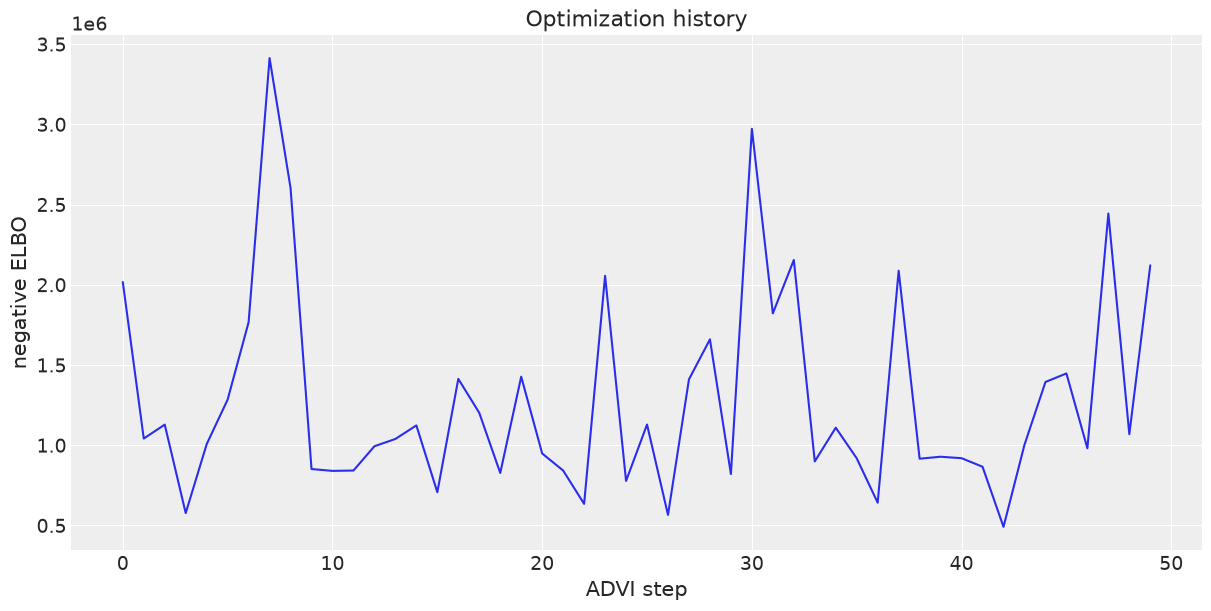

In [7]:
forecaster = Forecaster(
    retail_model,
    y_train,
    covariates_train,
    optimizer=LEARNING_RATE,
    backend="jax",
    num_steps=NUM_STEPS,
    random_seed=SEED,
    progressbar=False,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses, color="C0")
ax.set(xlabel="ADVI step", ylabel="negative ELBO", title="Optimization history")
plt.show()

## Memory-bounded posterior and predictive sampling

Sampling all posterior latents at once is the largest avoidable allocation: the two
time-by-series drift variable alone contains billions of values in a 500-draw
full-panel run. `batch_size=50` asks `pm.Approximation.sample` for only 50 draws at
a time. Each completed chunk is converted to a host-backed xarray dataset before
the next one is generated.

PyMC posterior prediction already compiles one forward function and calls it once
per posterior point, storing NumPy results on the host. We therefore pass the fixed,
batched posterior to both prediction calls; unlike the vectorized NumPyro path, no
full `(draw, time, series)` predictive tensor is live on the GPU.

In [8]:
posterior = forecaster.draw_posterior(
    NUM_SAMPLES,
    random_seed=SEED + 1,
    batch_size=POSTERIOR_BATCH_SIZE,
)
in_sample = forecaster.predict_in_sample(posterior=posterior, random_seed=SEED + 2)
sales_forecast = forecaster.forecast(
    covariates,
    posterior=posterior,
    random_seed=SEED + 3,
)

print(f"posterior sizes: {posterior.sizes}")
print(f"in-sample sizes: {in_sample.posterior_predictive['obs'].sizes}")
print(f"forecast sizes: {sales_forecast.predictions['forecast'].sizes}")
print(f"forecast storage: {type(sales_forecast.predictions['forecast'].values).__name__}")

Sampling: [obs]


Sampling: [drift_future, forecast, slope_innovation_future]


posterior sizes: Frozen({'chain': 1, 'draw': 20, 'feature': 4, 'store': 4, 'series': 12, 'time': 76, 'day_of_week': 7})
in-sample sizes: Frozen({'chain': 1, 'draw': 20, 'time': 76, 'series': 12})
forecast sizes: Frozen({'chain': 1, 'draw': 20, 'time_future': 14, 'series': 12})
forecast storage: ndarray


## Holdout evaluation

We return predictions to sale units, clip the Normal likelihood's small negative
tail at zero, and compare CRPS and interval coverage with a weekday-aligned seasonal
naive ensemble. The committed outputs come from the 50-step synthetic CI path and
only verify execution; run the full fit before interpreting model quality.

In [9]:
pred_scaled = sales_forecast.predictions["forecast"]
pred_sales = (pred_scaled * scale).clip(min=0.0)
truth = panel["sale_amount"].isel(time=slice(T_TRAIN, None)).rename(time="time_future")

model_scores = evaluate_forecast(pred_sales, truth)

history = panel["sale_amount"].isel(time=slice(None, T_TRAIN))
naive_windows = []
for weeks_back in range(2, 10):
    start = T_TRAIN - 7 * weeks_back
    if start >= 0 and start + HORIZON <= T_TRAIN:
        naive_windows.append(history.isel(time=slice(start, start + HORIZON)).values)
naive = xr.DataArray(
    np.stack(naive_windows),
    dims=("sample", "time_future", "series"),
    coords={"time_future": truth["time_future"], "series": panel["series"]},
)
naive_scores = evaluate_forecast(naive, truth)

pd.DataFrame([model_scores, naive_scores], index=["PyMC-Forecast", "seasonal naive"])

,mae,rmse,crps,coverage
PyMC-Forecast,57.138564,185.868855,57.324788,1.000000
seasonal naive,2.966174,3.960719,2.205881,0.696429


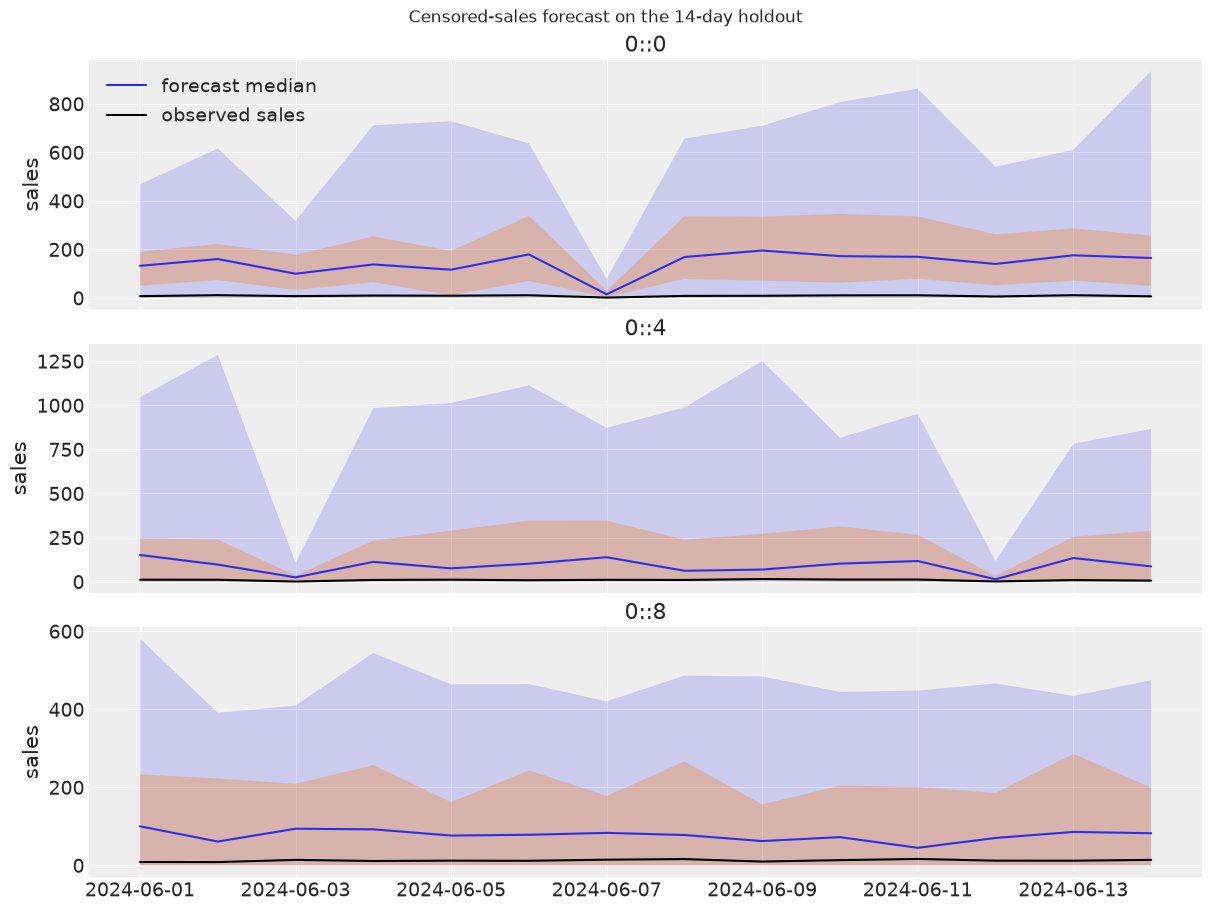

In [10]:
focus = series_ids[: min(3, n_series)]
quantiles = pred_sales.sel(series=focus).quantile(
    [0.03, 0.25, 0.5, 0.75, 0.97], dim=("chain", "draw")
)

fig, axes = plt.subplots(len(focus), 1, figsize=(12, 3 * len(focus)), sharex=True)
axes = np.atleast_1d(axes)
future_dates = truth["time_future"].values
for ax, label in zip(axes, focus, strict=True):
    q = quantiles.sel(series=label)
    ax.fill_between(future_dates, q.sel(quantile=0.03), q.sel(quantile=0.97), alpha=0.18)
    ax.fill_between(future_dates, q.sel(quantile=0.25), q.sel(quantile=0.75), alpha=0.3)
    ax.plot(future_dates, q.sel(quantile=0.5), color="C0", label="forecast median")
    ax.plot(future_dates, truth.sel(series=label), color="black", label="observed sales")
    ax.set(title=label, ylabel="sales")
axes[0].legend()
fig.suptitle("Censored-sales forecast on the 14-day holdout")
plt.show()

## From sales to demand

Future availability is unknowable at ordering time. Setting it to one asks a clean
counterfactual: how much would sell if every product remained fully stocked? All
posterior parameters and random effects stay fixed; only the future input changes.

Sampling: [drift_future, forecast, slope_innovation_future]


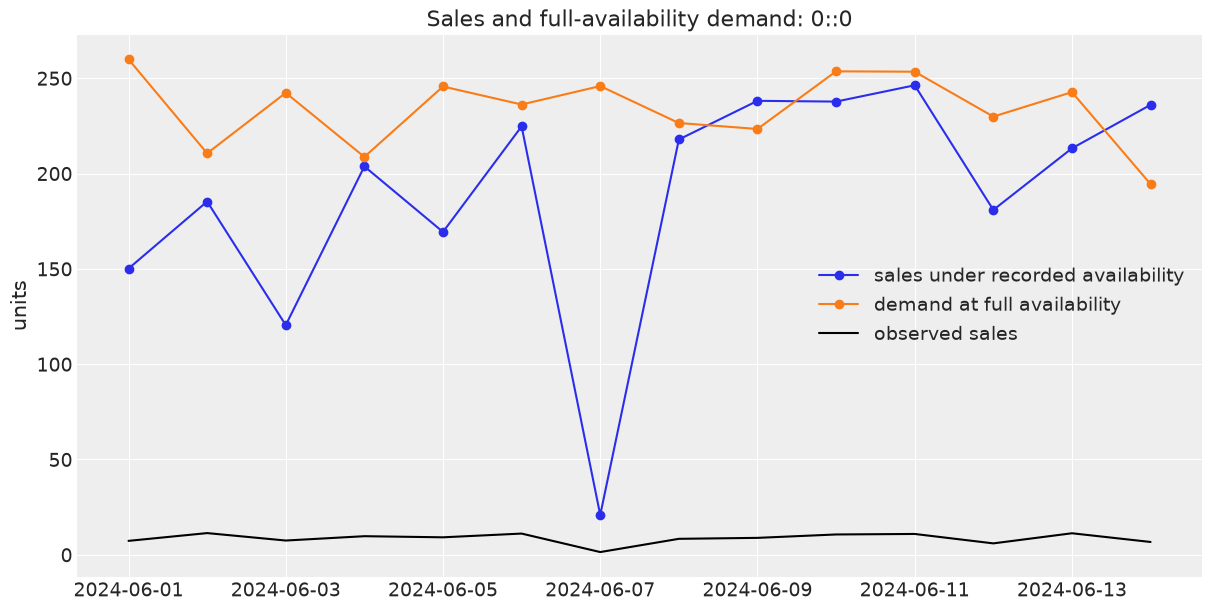

mean demand uplift at full availability: 11.8%


In [11]:
demand_covariates = covariates.copy(deep=True)
demand_covariates.loc[
    {"time": demand_covariates["time"].values[T_TRAIN:], "input": "availability"}
] = 1.0

demand_forecast = forecaster.forecast(
    demand_covariates,
    posterior=posterior,
    random_seed=SEED + 4,
)
pred_demand = (demand_forecast.predictions["forecast"] * scale).clip(min=0.0)

label = focus[0]
sales_mean = pred_sales.sel(series=label).mean(("chain", "draw"))
demand_mean = pred_demand.sel(series=label).mean(("chain", "draw"))

fig, ax = plt.subplots()
ax.plot(future_dates, sales_mean, marker="o", label="sales under recorded availability")
ax.plot(future_dates, demand_mean, marker="o", label="demand at full availability")
ax.plot(future_dates, truth.sel(series=label), color="black", label="observed sales")
ax.set(title=f"Sales and full-availability demand: {label}", ylabel="units")
ax.legend()
plt.show()

print(
    "mean demand uplift at full availability: "
    f"{float((pred_demand.mean() / pred_sales.mean() - 1) * 100):.1f}%"
)

## Takeaways

- Named xarray dimensions keep 50,000 series, five inputs, 898 stores, and two time
  ranges aligned without positional axis conventions.
- JAX accelerates ADVI, while `draw_posterior(..., batch_size=50)` bounds the largest
  posterior allocation and returns each chunk to host memory.
- PyMC posterior prediction is point-wise and host-backed, so replaying the same
  posterior for in-sample, sales, and demand scenarios does not materialize a
  vectorized predictive panel on the accelerator.
- The availability factor separates censored sales from latent demand; setting
  future availability to one produces an actionable ordering forecast.